📥 1. Baixando o dataset do Kaggle...
Dataset URL: https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset
License(s): other
wildfire-prediction-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)

📦 2. Descompactando os arquivos...
replace /content/wildfire_data/test/nowildfire/-113.91777,50.901087.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A

📂 3. Criando geradores de dados em lotes...
Found 30250 images belonging to 2 classes.
Found 6300 images belonging to 2 classes.
Found 6300 images belonging to 2 classes.

🧠 4. Montando a arquitetura com MobileNetV2...


/tmp/ipykernel_32626/3973023013.py:54: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(350, 350, 3))



🚀 5. Iniciando o treinamento expresso na GPU T4...
Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 518s 5s/step - accuracy: 0.9094 - loss: 0.2302 - val_accuracy: 0.9453 - val_loss: 0.1490
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 565s 6s/step - accuracy: 0.9388 - loss: 0.1717 - val_accuracy: 0.9656 - val_loss: 0.1045
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 541s 5s/step - accuracy: 0.9466 - loss: 0.1482 - val_accuracy: 0.9219 - val_loss: 0.1856

✅ Treinamento concluído! Iniciando avaliação final nas imagens de teste...
197/197 ━━━━━━━━━━━━━━━━━━━━ 777s 4s/step


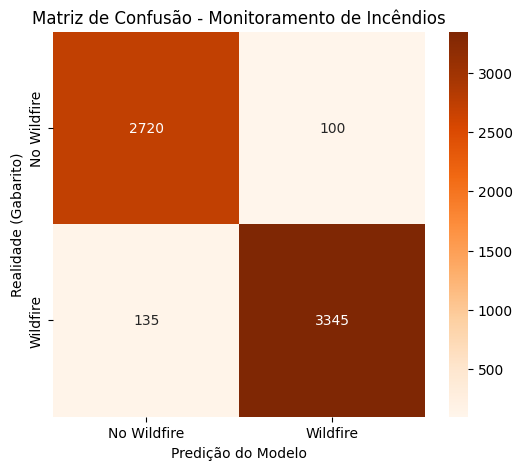


--- Relatório de Classificação Final ---
              precision    recall  f1-score   support

 No Wildfire       0.95      0.96      0.96      2820
    Wildfire       0.97      0.96      0.97      3480

    accuracy                           0.96      6300
   macro avg       0.96      0.96      0.96      6300
weighted avg       0.96      0.96      0.96      6300

🏅 ROC AUC Score Final: 0.9933


In [5]:
import os
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 🛠️ CORREÇÃO PIL: Ignora imagens corrompidas do dataset automaticamente
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ==========================================================
# 1. DOWNLOAD E EXTRAÇÃO DOS DADOS
# ==========================================================
print("📥 1. Baixando o dataset do Kaggle...")
os.environ['KAGGLE_API_TOKEN'] = 'projeto fiap'
!kaggle datasets download -d abdelghaniaaba/wildfire-prediction-dataset

print("\n📦 2. Descompactando os arquivos...")
!unzip -q wildfire-prediction-dataset.zip -d /content/wildfire_data

# ==========================================================
# 2. CONFIGURANDO OS GERADORES DE IMAGENS
# ==========================================================
print("\n📂 3. Criando geradores de dados em lotes...")
base_path = '/content/wildfire_data'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    vertical_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    f'{base_path}/train', target_size=(350, 350), batch_size=32, class_mode='binary'
)
val_generator = val_test_datagen.flow_from_directory(
    f'{base_path}/valid', target_size=(350, 350), batch_size=32, class_mode='binary'
)
test_generator = val_test_datagen.flow_from_directory(
    f'{base_path}/test', target_size=(350, 350), batch_size=32, class_mode='binary', shuffle=False
)

# ==========================================================
# 3. CONSTRUINDO A REDE NEURAL (MobileNetV2)
# ==========================================================
print("\n🧠 4. Montando a arquitetura com MobileNetV2...")
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(350, 350, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ==========================================================
# 4. TREINAMENTO EXPRESSO DE ALTA PERFORMANCE
# ==========================================================
print("\n🚀 5. Iniciando o treinamento expresso na GPU T4...")
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=3,
    validation_data=val_generator,
    validation_steps=20,
    callbacks=[early_stop]
)

print("\n✅ Treinamento concluído! Iniciando avaliação final nas imagens de teste...")

# ==========================================================
# 5. AVALIAÇÃO DE MÉTRICAS (Matriz de Confusão Sem Quebras)
# ==========================================================
predictions = model.predict(test_generator)
y_pred = np.where(predictions > 0.5, 1, 0)
y_true = test_generator.classes

# Plotando o gráfico final
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Wildfire', 'Wildfire'], yticklabels=['No Wildfire', 'Wildfire'])
plt.ylabel('Realidade (Gabarito)')
plt.xlabel('Predição do Modelo')
plt.title('Matriz de Confusão - Monitoramento de Incêndios')
plt.show()

print("\n--- Relatório de Classificação Final ---")
print(classification_report(y_true, y_pred, target_names=['No Wildfire', 'Wildfire']))
print(f"🏅 ROC AUC Score Final: {roc_auc_score(y_true, predictions):.4f}")
